In [1]:


import sys
import importlib
from pathlib import Path

CODE_DIR = Path("/content/drive/MyDrive/ASR_Project/ASR_finalproject_AllisonWivagg_YeritmaryR/FINAL_Codes")

if str(CODE_DIR) not in sys.path:
    sys.path.append(str(CODE_DIR))

import segmentation
importlib.reload(segmentation)
from segmentation import *

print("segmentation.py imported successfully")
print("CODE_DIR:", CODE_DIR)
print("segmentation.py exists:", (CODE_DIR / "segmentation.py").exists())

segmentation.py imported successfully
CODE_DIR: /content/drive/MyDrive/ASR_Project/ASR_finalproject_AllisonWivagg_YeritmaryR/FINAL_Codes
segmentation.py exists: True


In [2]:
# Set project paths

ROOT = Path("/content/drive/MyDrive/ASR_Project/ASR_finalproject_AllisonWivagg_YeritmaryR")

DATA_DIR = ROOT / "data"
OUT_DIR = ROOT / "outputs"
OUT_DIR.mkdir(parents=True, exist_ok=True)

COMB_IMG = DATA_DIR / "combined" / "images"
COMB_MASK = DATA_DIR / "combined" / "masks"

print("COMB_IMG exists:", COMB_IMG.exists())
print("COMB_MASK exists:", COMB_MASK.exists())

print("number images:", len(listimgs(COMB_IMG)))
print("number masks:", len(listimgs(COMB_MASK)))

COMB_IMG exists: True
COMB_MASK exists: True
number images: 966
number masks: 966


In [3]:
# Set device and random seeds
# Use selectedSeed for this notebook run.
# You can rerun the whole notebook with selectedSeed = 7 or 123 to check seed sensitivity.

seeds = [42, 7, 123]
selectedSeed = 42

setSeed(selectedSeed)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", DEVICE)
print("Available seeds:", seeds)
print("Current selected seed:", selectedSeed)

Using device: cuda
Available seeds: [42, 7, 123]
Current selected seed: 42


In [4]:
# Pair image and mask files for the combined dataset

combinedTable = pairFiles(COMB_IMG, COMB_MASK, "combined")

print("Matched image-mask pairs:", len(combinedTable))
print(combinedTable.head())

print("Example image files:")
for p in listimgs(COMB_IMG)[:10]:
    print(p.name)

print("\nExample mask files:")
for p in listimgs(COMB_MASK)[:10]:
    print(p.name)

Matched image-mask pairs: 966
         image_id                                         image_path  \
0  bbbc006_a01_s1  /content/drive/MyDrive/ASR_Project/ASR_finalpr...   
1  bbbc006_a01_s2  /content/drive/MyDrive/ASR_Project/ASR_finalpr...   
2  bbbc006_a02_s1  /content/drive/MyDrive/ASR_Project/ASR_finalpr...   
3  bbbc006_a02_s2  /content/drive/MyDrive/ASR_Project/ASR_finalpr...   
4  bbbc006_a03_s1  /content/drive/MyDrive/ASR_Project/ASR_finalpr...   

                                           mask_path    source  
0  /content/drive/MyDrive/ASR_Project/ASR_finalpr...  combined  
1  /content/drive/MyDrive/ASR_Project/ASR_finalpr...  combined  
2  /content/drive/MyDrive/ASR_Project/ASR_finalpr...  combined  
3  /content/drive/MyDrive/ASR_Project/ASR_finalpr...  combined  
4  /content/drive/MyDrive/ASR_Project/ASR_finalpr...  combined  
Example image files:
bbbc006_a01_s1.png
bbbc006_a01_s2.png
bbbc006_a02_s1.png
bbbc006_a02_s2.png
bbbc006_a03_s1.png
bbbc006_a03_s2.png
bbbc006_a04_

In [5]:
# Split into training, validation, and test tables

trainingTable, validationTable, testTable = splitData(
    combinedTable,
    seed=selectedSeed,
    trainSize=0.70,
    validationSize=0.15,
    testSize=0.15
)

print("training size:", len(trainingTable))
print("validation size:", len(validationTable))
print("test size:", len(testTable))

training size: 676
validation size: 145
test size: 145


In [6]:
# Create full segmentation datasets

trainingSet = SegSet(trainingTable, size=(256, 256), mode="gray")
validationSet = SegSet(validationTable, size=(256, 256), mode="gray")
testSet = SegSet(testTable, size=(256, 256), mode="gray")

print("training dataset size:", len(trainingSet))
print("validation dataset size:", len(validationSet))
print("test dataset size:", len(testSet))

training dataset size: 676
validation dataset size: 145
test dataset size: 145


image shape: torch.Size([1, 256, 256])
mask shape: torch.Size([1, 256, 256])
image id: bbbc006_o01_s1
source: combined
split: train


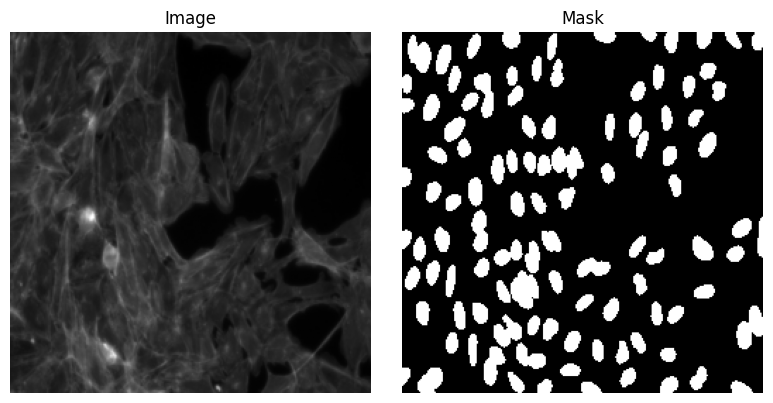

In [7]:
# Check one image-mask pair

sample = trainingSet[0]

print("image shape:", sample["image"].shape)
print("mask shape:", sample["mask"].shape)
print("image id:", sample["image_id"])
print("source:", sample["source"])
print("split:", sample["split"])

plt.figure(figsize=(8, 4))

plt.subplot(1, 2, 1)
plt.imshow(sample["image"].squeeze().numpy(), cmap="gray")
plt.title("Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(sample["mask"].squeeze().numpy(), cmap="gray")
plt.title("Mask")
plt.axis("off")

plt.tight_layout()
plt.show()

In [8]:
# Passive learning subset creation function

def makePassiveSubset(dataset, numberOfSamples=120, seed=42):
    setSeed(seed)

    allIndexes = list(range(len(dataset)))
    random.shuffle(allIndexes)

    selectedIndexes = allIndexes[:numberOfSamples]

    subset = torch.utils.data.Subset(dataset, selectedIndexes)

    return subset, selectedIndexes

In [9]:
# Create shared warm-up set for the combined dataset

warmupTrainingSet, warmupIndexes = makePassiveSubset(
    dataset=trainingSet,
    numberOfSamples=40,
    seed=selectedSeed
)

print("warm-up training size:", len(warmupTrainingSet))
print("first warm-up indexes:", warmupIndexes[:10])

warm-up training size: 40
first warm-up indexes: [172, 525, 609, 118, 42, 359, 395, 312, 2, 510]


In [10]:
# Passive subset with the same warm-up start as active learning

def makePassiveSubsetWithWarmup(dataset, warmupIndexes, numberOfSamples=120, seed=42):
    setSeed(seed)

    allIndexes = list(range(len(dataset)))

    remainingIndexes = [
        index for index in allIndexes
        if index not in warmupIndexes
    ]

    random.shuffle(remainingIndexes)

    numberToAdd = numberOfSamples - len(warmupIndexes)

    newPassiveIndexes = remainingIndexes[:numberToAdd]

    selectedIndexes = warmupIndexes + newPassiveIndexes

    subset = torch.utils.data.Subset(dataset, selectedIndexes)

    return subset, selectedIndexes

In [11]:
# Create passive learning subset for the combined dataset

passiveTrainingSet, passiveIndexes = makePassiveSubsetWithWarmup(
    dataset=trainingSet,
    warmupIndexes=warmupIndexes,
    numberOfSamples=120,
    seed=selectedSeed
)

print("passive training size:", len(passiveTrainingSet))
print("first passive indexes:", passiveIndexes[:10])

passive training size: 120
first passive indexes: [172, 525, 609, 118, 42, 359, 395, 312, 2, 510]


In [12]:
# Create warm-up loader for active learning

warmupTrainingLoader = makeLoader(
    warmupTrainingSet,
    batchSize=4,
    shuffle=True
)

validationLoader = makeLoader(
    validationSet,
    batchSize=4,
    shuffle=False
)

print("warm-up loader batches:", len(warmupTrainingLoader))
print("validation loader batches:", len(validationLoader))

warm-up loader batches: 10
validation loader batches: 37


In [13]:
# Train warm-up model before active selection

warmupNetwork = UNet(
    inputChannels=1,
    outputChannels=1,
    dropoutRate=0.3
).to(DEVICE)

warmupTrainedNetwork, warmupHistoryTable = trainNetwork(
    network=warmupNetwork,
    trainingLoader=warmupTrainingLoader,
    validationLoader=validationLoader,
    device=DEVICE,
    numEpochs=5,
    learningRate=1e-3,
    savingPath=None
)

warmupHistoryTable

Epoch 1/5 | Batch 1/10 | Loss: 1.4973
Epoch 1/5 | Train Loss: 1.3489 | Validation Loss: 1.3479 | Validation Dice: 0.0068 | Validation IoU: 0.0068
Epoch 2/5 | Batch 1/10 | Loss: 1.2118
Epoch 2/5 | Train Loss: 1.2313 | Validation Loss: 1.3576 | Validation Dice: 0.6709 | Validation IoU: 0.5463
Epoch 3/5 | Batch 1/10 | Loss: 1.0276
Epoch 3/5 | Train Loss: 1.1709 | Validation Loss: 1.3810 | Validation Dice: 0.4043 | Validation IoU: 0.2606
Epoch 4/5 | Batch 1/10 | Loss: 1.3218
Epoch 4/5 | Train Loss: 1.1316 | Validation Loss: 1.0564 | Validation Dice: 0.7068 | Validation IoU: 0.5974
Epoch 5/5 | Batch 1/10 | Loss: 1.0855
Epoch 5/5 | Train Loss: 1.0885 | Validation Loss: 0.9804 | Validation Dice: 0.6780 | Validation IoU: 0.5547


,epoch,trainLoss,validationLoss,validationDice,validationIoU
0,1,1.348923,1.347911,0.006757,0.006757
1,2,1.231313,1.357567,0.670923,0.546273
2,3,1.170946,1.381011,0.404290,0.260618
3,4,1.131638,1.056391,0.706807,0.597434
4,5,1.088472,0.980433,0.678047,0.554743


In [ ]:
# Active learning selection method
# The MC dropout activelearning function is imported from segmentation.py.


print("Using makeActiveSubsetMCDropout() from segmentation.py")

Using makeActiveSubsetMCDropout() from segmentation.py


In [15]:
# Create active learning subset for the combined dataset using MC dropout uncertainty

activeTrainingSet, activeIndexes, uncertaintyTable = makeActiveSubsetMCDropout(
    dataset=trainingSet,
    trainedNetwork=warmupTrainedNetwork,
    device=DEVICE,
    warmupIndexes=warmupIndexes,
    numberOfSamples=120,
    batchSize=16,
    numMCSamples=5
)

print("active training size:", len(activeTrainingSet))
print("first active indexes:", activeIndexes[:10])
print(uncertaintyTable.head().to_string(index=False))

active training size: 120
first active indexes: [172, 525, 609, 118, 42, 359, 395, 312, 2, 510]
 index  uncertainty
   355     0.133788
   226     0.124915
   340     0.121496
   668     0.120592
   552     0.113301


In [16]:
# Check that passive and active use the same total label budget

print("passive size:", len(passiveTrainingSet))
print("active size:", len(activeTrainingSet))

print("warmup size:", len(warmupIndexes))
print("passive unique indexes:", len(set(passiveIndexes)))
print("active unique indexes:", len(set(activeIndexes)))

print("same warmup in passive:", set(warmupIndexes).issubset(set(passiveIndexes)))
print("same warmup in active:", set(warmupIndexes).issubset(set(activeIndexes)))

print("passive-active overlap:", len(set(passiveIndexes) & set(activeIndexes)))

passive size: 120
active size: 120
warmup size: 40
passive unique indexes: 120
active unique indexes: 120
same warmup in passive: True
same warmup in active: True
passive-active overlap: 50


In [17]:
# Train passive learning model

passiveTrainingLoader = makeLoader(
    passiveTrainingSet,
    batchSize=4,
    shuffle=True
)

validationLoader = makeLoader(
    validationSet,
    batchSize=4,
    shuffle=False
)

passiveNetwork = UNet(
    inputChannels=1,
    outputChannels=1,
    dropoutRate=0.3
).to(DEVICE)

passiveTrainedNetwork, passiveHistoryTable = trainNetwork(
    network=passiveNetwork,
    trainingLoader=passiveTrainingLoader,
    validationLoader=validationLoader,
    device=DEVICE,
    numEpochs=5,
    learningRate=1e-3,
    savingPath=None
)

passiveHistoryTable

Epoch 1/5 | Batch 1/30 | Loss: 1.3734
Epoch 1/5 | Batch 11/30 | Loss: 1.3555
Epoch 1/5 | Batch 21/30 | Loss: 1.3379
Epoch 1/5 | Train Loss: 1.2288 | Validation Loss: 1.1628 | Validation Dice: 0.7188 | Validation IoU: 0.6187
Epoch 2/5 | Batch 1/30 | Loss: 0.9075
Epoch 2/5 | Batch 11/30 | Loss: 0.8737
Epoch 2/5 | Batch 21/30 | Loss: 0.9545
Epoch 2/5 | Train Loss: 1.0599 | Validation Loss: 0.8772 | Validation Dice: 0.7021 | Validation IoU: 0.5893
Epoch 3/5 | Batch 1/30 | Loss: 0.9079
Epoch 3/5 | Batch 11/30 | Loss: 0.9248
Epoch 3/5 | Batch 21/30 | Loss: 0.9369
Epoch 3/5 | Train Loss: 0.9527 | Validation Loss: 0.7162 | Validation Dice: 0.6103 | Validation IoU: 0.5521
Epoch 4/5 | Batch 1/30 | Loss: 1.2852
Epoch 4/5 | Batch 11/30 | Loss: 0.8981
Epoch 4/5 | Batch 21/30 | Loss: 0.8205
Epoch 4/5 | Train Loss: 0.8964 | Validation Loss: 0.7014 | Validation Dice: 0.5846 | Validation IoU: 0.5389
Epoch 5/5 | Batch 1/30 | Loss: 0.8594
Epoch 5/5 | Batch 11/30 | Loss: 0.7175
Epoch 5/5 | Batch 21/30 | L

,epoch,trainLoss,validationLoss,validationDice,validationIoU
0,1,1.228793,1.162803,0.718794,0.618746
1,2,1.059898,0.877182,0.702098,0.589303
2,3,0.952663,0.716181,0.610306,0.552127
3,4,0.896431,0.701399,0.584628,0.538864
4,5,0.861140,0.677828,0.636017,0.559527


In [18]:
# Train active learning model

activeTrainingLoader = makeLoader(
    activeTrainingSet,
    batchSize=4,
    shuffle=True
)

activeNetwork = UNet(
    inputChannels=1,
    outputChannels=1,
    dropoutRate=0.3
).to(DEVICE)

activeTrainedNetwork, activeHistoryTable = trainNetwork(
    network=activeNetwork,
    trainingLoader=activeTrainingLoader,
    validationLoader=validationLoader,
    device=DEVICE,
    numEpochs=5,
    learningRate=1e-3,
    savingPath=None
)

activeHistoryTable

Epoch 1/5 | Batch 1/30 | Loss: 1.5834
Epoch 1/5 | Batch 11/30 | Loss: 0.9561
Epoch 1/5 | Batch 21/30 | Loss: 0.9434
Epoch 1/5 | Train Loss: 1.0825 | Validation Loss: 1.2648 | Validation Dice: 0.5022 | Validation IoU: 0.3771
Epoch 2/5 | Batch 1/30 | Loss: 0.8364
Epoch 2/5 | Batch 11/30 | Loss: 0.7958
Epoch 2/5 | Batch 21/30 | Loss: 0.9183
Epoch 2/5 | Train Loss: 0.8837 | Validation Loss: 0.8965 | Validation Dice: 0.7306 | Validation IoU: 0.6377
Epoch 3/5 | Batch 1/30 | Loss: 0.7258
Epoch 3/5 | Batch 11/30 | Loss: 0.8765
Epoch 3/5 | Batch 21/30 | Loss: 0.7920
Epoch 3/5 | Train Loss: 0.7788 | Validation Loss: 0.9224 | Validation Dice: 0.7349 | Validation IoU: 0.6447
Epoch 4/5 | Batch 1/30 | Loss: 0.8764
Epoch 4/5 | Batch 11/30 | Loss: 0.8025
Epoch 4/5 | Batch 21/30 | Loss: 0.5766
Epoch 4/5 | Train Loss: 0.7015 | Validation Loss: 0.8266 | Validation Dice: 0.7398 | Validation IoU: 0.6505
Epoch 5/5 | Batch 1/30 | Loss: 0.5514
Epoch 5/5 | Batch 11/30 | Loss: 0.6158
Epoch 5/5 | Batch 21/30 | L

,epoch,trainLoss,validationLoss,validationDice,validationIoU
0,1,1.082504,1.264803,0.502231,0.377078
1,2,0.883730,0.896517,0.730569,0.637735
2,3,0.778804,0.922426,0.734861,0.644672
3,4,0.701522,0.826619,0.739800,0.650521
4,5,0.646842,0.670686,0.681547,0.607173


In [19]:
# Evaluate passive and active models on the same test set

testLoader = makeLoader(testSet, batchSize=4, shuffle=False)

lossFunction = SegLoss()

passiveTestResults = evaluateNetwork(
    network=passiveTrainedNetwork,
    dataLoader=testLoader,
    lossFunction=lossFunction,
    device=DEVICE
)

activeTestResults = evaluateNetwork(
    network=activeTrainedNetwork,
    dataLoader=testLoader,
    lossFunction=lossFunction,
    device=DEVICE
)

print("Passive test results:")
print(passiveTestResults)

print("\nActive test results:")
print(activeTestResults)

Passive test results:
{'loss': 0.7589636904162329, 'dice': 0.5726183538602011, 'iou': 0.50175376014935}

Active test results:
{'loss': 0.7531233260760436, 'dice': 0.6233240144478308, 'iou': 0.546750662294594}


In [20]:
# Compare passive and active learning results

comparisonTable = pd.DataFrame([
    {
        "dataset": "combined",
        "seed": selectedSeed,
        "strategy": "passive",
        "selection_method": "random_with_shared_warmup",
        "training_samples": len(passiveTrainingSet),
        "test_loss": passiveTestResults["loss"],
        "test_dice": passiveTestResults["dice"],
        "test_iou": passiveTestResults["iou"]
    },
    {
        "dataset": "combined",
        "seed": selectedSeed,
        "strategy": "active",
        "selection_method": "mc_dropout_uncertainty",
        "training_samples": len(activeTrainingSet),
        "test_loss": activeTestResults["loss"],
        "test_dice": activeTestResults["dice"],
        "test_iou": activeTestResults["iou"]
    }
])

print(comparisonTable.to_string(index=False))

 dataset  seed strategy          selection_method  training_samples  test_loss  test_dice  test_iou
combined    42  passive random_with_shared_warmup               120   0.758964   0.572618  0.501754
combined    42   active    mc_dropout_uncertainty               120   0.753123   0.623324  0.546751


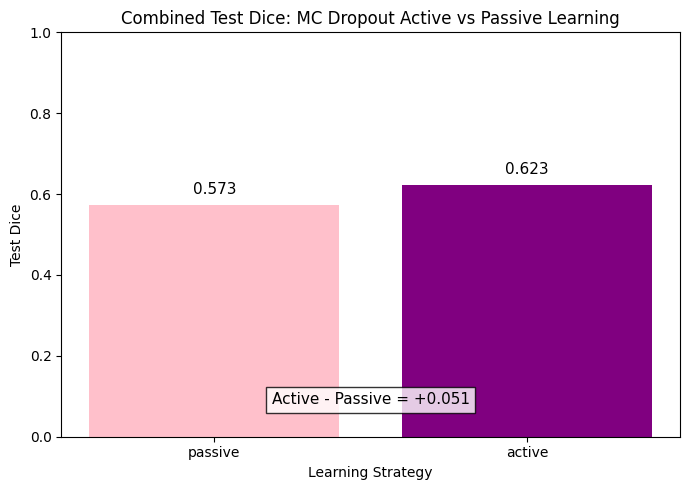

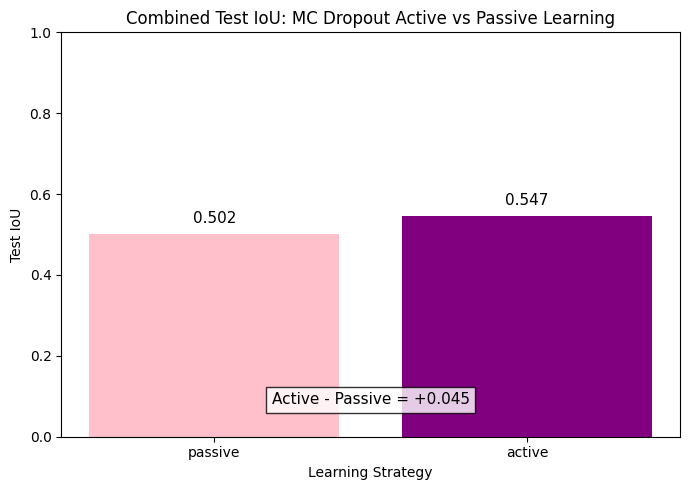

In [21]:
# More informative Dice and IoU comparison plots for the combined dataset
# These plots show final held-out test performance for passive vs active learning.

barColors = ["pink", "purple"]

metrics = [
    ("test_dice", "Dice"),
    ("test_iou", "IoU")
]

for metricColumn, metricName in metrics:
    passiveValue = comparisonTable.loc[
        comparisonTable["strategy"] == "passive", metricColumn
    ].iloc[0]

    activeValue = comparisonTable.loc[
        comparisonTable["strategy"] == "active", metricColumn
    ].iloc[0]

    difference = activeValue - passiveValue

    plt.figure(figsize=(7, 5))

    bars = plt.bar(
        comparisonTable["strategy"],
        comparisonTable[metricColumn],
        color=barColors
    )

    plt.ylabel(f"Test {metricName}")
    plt.xlabel("Learning Strategy")
    plt.title(f"Combined Test {metricName}: MC Dropout Active vs Passive Learning")
    plt.ylim(0, 1)

    # Add exact values above bars
    for bar in bars:
        height = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            height + 0.02,
            f"{height:.3f}",
            ha="center",
            va="bottom",
            fontsize=11
        )

    # Add active minus passive difference
    plt.text(
        0.5,
        0.08,
        f"Active - Passive = {difference:+.3f}",
        ha="center",
        fontsize=11,
        bbox=dict(facecolor="white", alpha=0.8)
    )

    plt.tight_layout()
    plt.show()

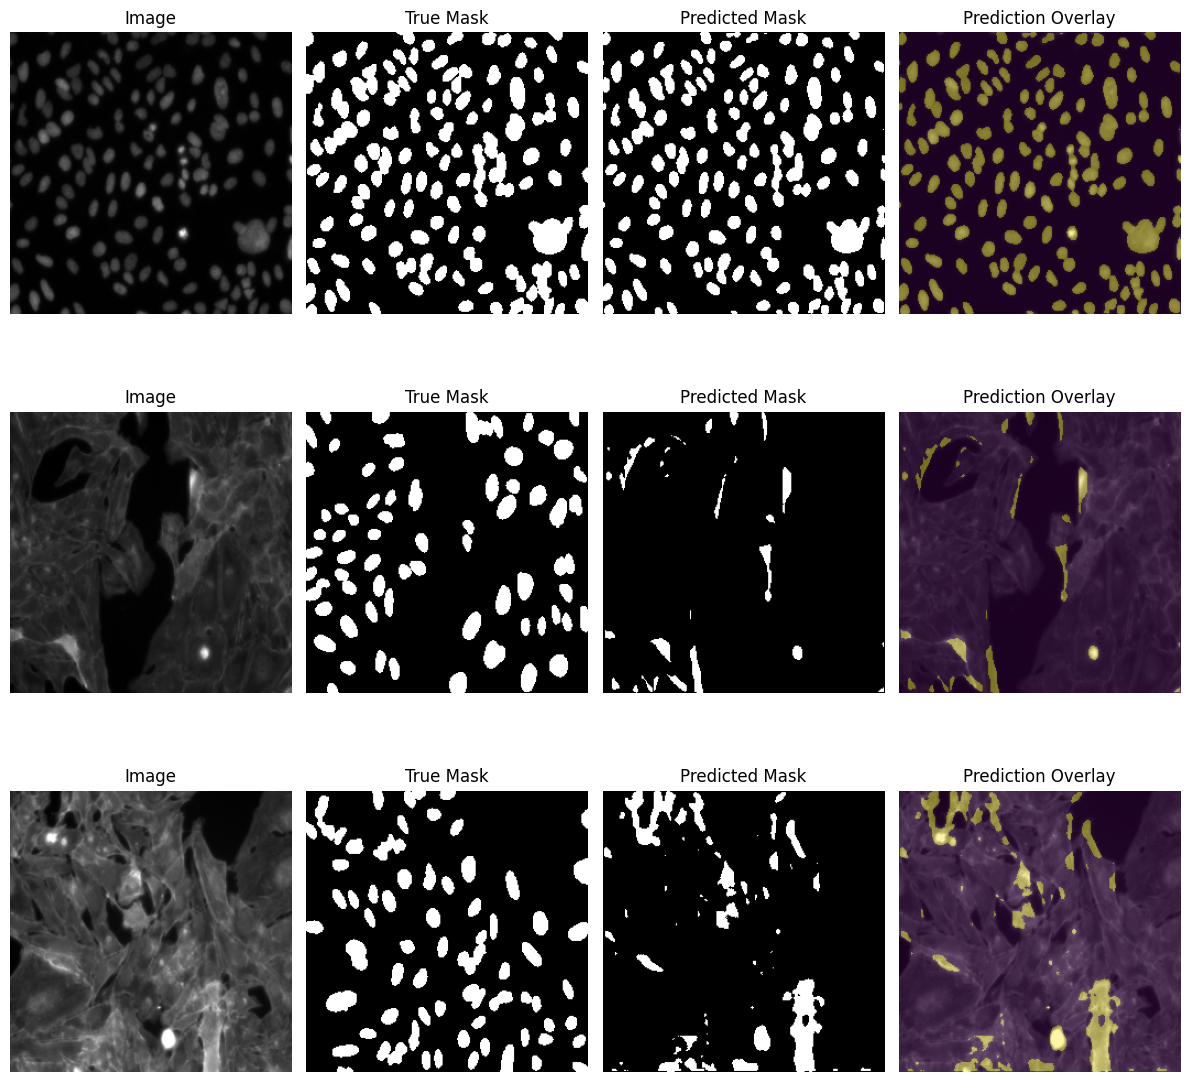

In [22]:
# Show passive model predictions

showPredictions(
    network=passiveTrainedNetwork,
    dataset=testSet,
    device=DEVICE,
    numberOfImages=3,
    threshold=0.5
)

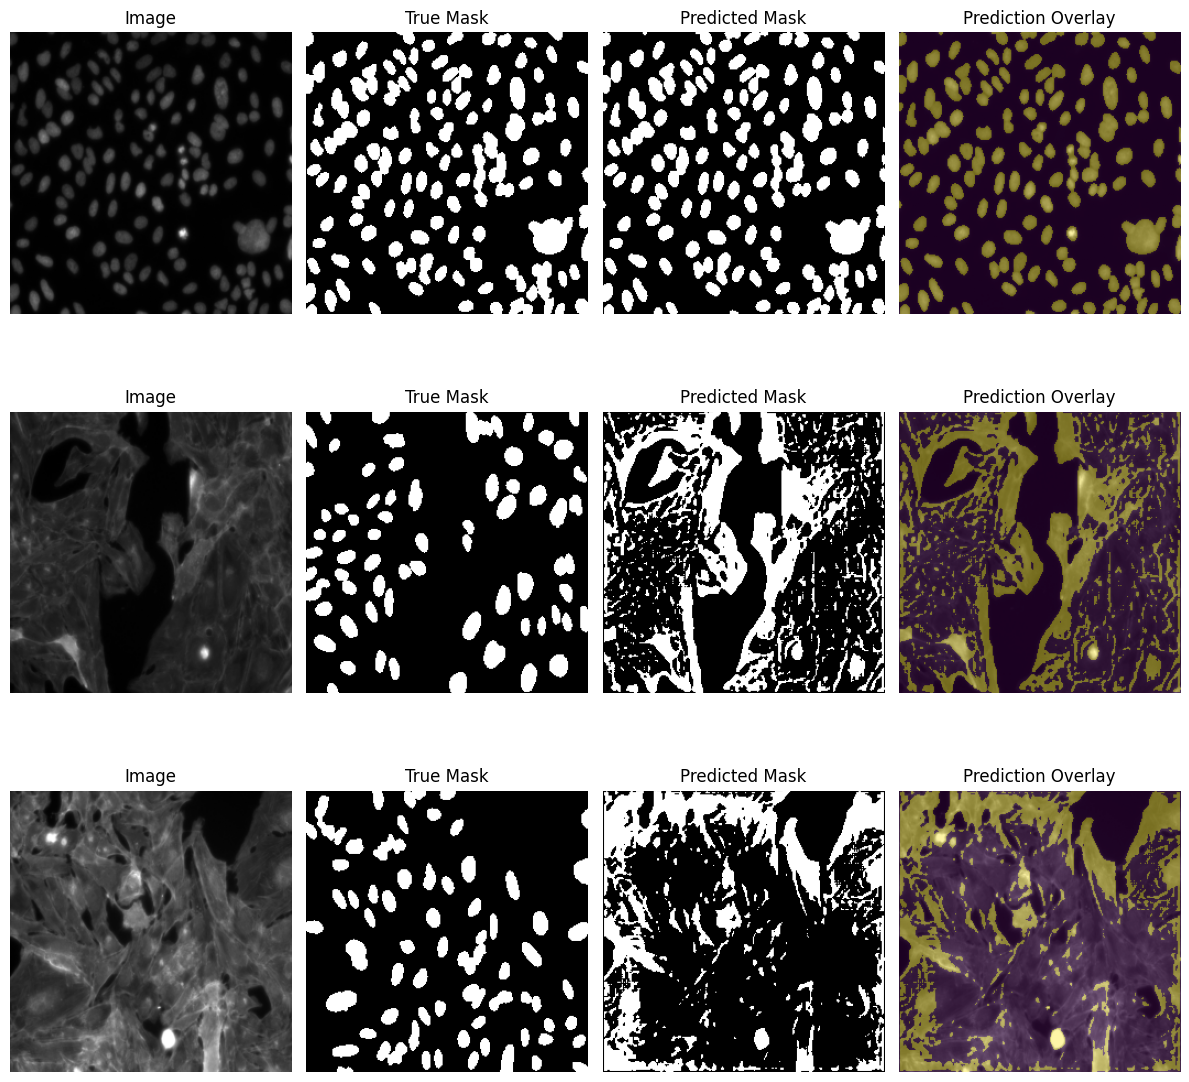

In [23]:
# Show active model predictions

showPredictions(
    network=activeTrainedNetwork,
    dataset=testSet,
    device=DEVICE,
    numberOfImages=3,
    threshold=0.5
)

In [24]:
# Save combined active/passive comparison results

combinedComparisonPath = OUT_DIR / f"combined_active_passive_comparison_MCdropout_seed{selectedSeed}.csv"
comparisonTable.to_csv(combinedComparisonPath, index=False)

passiveHistoryPath = OUT_DIR / f"combined_passive_history_seed{selectedSeed}.csv"
activeHistoryPath = OUT_DIR / f"combined_active_MCdropout_history_seed{selectedSeed}.csv"
warmupHistoryPath = OUT_DIR / f"combined_warmup_history_seed{selectedSeed}.csv"

passiveHistoryTable.to_csv(passiveHistoryPath, index=False)
activeHistoryTable.to_csv(activeHistoryPath, index=False)
warmupHistoryTable.to_csv(warmupHistoryPath, index=False)

print("Saved comparison table to:", combinedComparisonPath)
print("Saved passive history to:", passiveHistoryPath)
print("Saved active history to:", activeHistoryPath)
print("Saved warm-up history to:", warmupHistoryPath)

Saved comparison table to: /content/drive/MyDrive/ASR_Project/ASR_finalproject_AllisonWivagg_YeritmaryR/outputs/combined_active_passive_comparison_MCdropout_seed42.csv
Saved passive history to: /content/drive/MyDrive/ASR_Project/ASR_finalproject_AllisonWivagg_YeritmaryR/outputs/combined_passive_history_seed42.csv
Saved active history to: /content/drive/MyDrive/ASR_Project/ASR_finalproject_AllisonWivagg_YeritmaryR/outputs/combined_active_MCdropout_history_seed42.csv
Saved warm-up history to: /content/drive/MyDrive/ASR_Project/ASR_finalproject_AllisonWivagg_YeritmaryR/outputs/combined_warmup_history_seed42.csv


In [25]:
# Compare ground truth, passive prediction, and active prediction on the same test images

def calculateSingleImageMetrics(predictedMask, trueMask, epsilon=1e-7):
    predictedMask = predictedMask.astype(np.float32)
    trueMask = trueMask.astype(np.float32)

    intersection = np.sum(predictedMask * trueMask)
    predictedArea = np.sum(predictedMask)
    trueArea = np.sum(trueMask)
    union = predictedArea + trueArea - intersection

    dice = (2 * intersection + epsilon) / (predictedArea + trueArea + epsilon)
    iou = (intersection + epsilon) / (union + epsilon)

    return dice, iou


def showPassiveActiveComparison(
    passiveNetwork,
    activeNetwork,
    dataset,
    device,
    numberOfImages=3,
    threshold=0.5,
    figureTitle="Passive vs Active Prediction Comparison"
):
    passiveNetwork.eval()
    activeNetwork.eval()

    plt.figure(figsize=(16, 4 * numberOfImages))

    for imageIndex in range(numberOfImages):
        sample = dataset[imageIndex]

        imageTensor = sample["image"].unsqueeze(0).to(device)
        imageToShow = sample["image"].squeeze().cpu().numpy()
        trueMask = sample["mask"].squeeze().cpu().numpy()

        with torch.no_grad():
            passiveLogits = passiveNetwork(imageTensor)
            passiveProbabilities = torch.sigmoid(passiveLogits)
            passiveMask = passiveProbabilities.squeeze().cpu().numpy()
            passiveBinaryMask = (passiveMask > threshold).astype(np.float32)

            activeLogits = activeNetwork(imageTensor)
            activeProbabilities = torch.sigmoid(activeLogits)
            activeMask = activeProbabilities.squeeze().cpu().numpy()
            activeBinaryMask = (activeMask > threshold).astype(np.float32)

        passiveDice, passiveIoU = calculateSingleImageMetrics(
            passiveBinaryMask,
            trueMask
        )

        activeDice, activeIoU = calculateSingleImageMetrics(
            activeBinaryMask,
            trueMask
        )

        # Column 1: original image
        plt.subplot(numberOfImages, 4, imageIndex * 4 + 1)
        plt.imshow(imageToShow, cmap="gray")
        plt.title("Image")
        plt.axis("off")

        # Column 2: ground truth
        plt.subplot(numberOfImages, 4, imageIndex * 4 + 2)
        plt.imshow(trueMask, cmap="gray")
        plt.title("Ground Truth Mask")
        plt.axis("off")

        # Column 3: passive predicted mask
        plt.subplot(numberOfImages, 4, imageIndex * 4 + 3)
        plt.imshow(passiveBinaryMask, cmap="gray")
        plt.title(
            f"Passive Prediction\nDice={passiveDice:.3f}, IoU={passiveIoU:.3f}"
        )
        plt.axis("off")

        # Column 4: active predicted mask
        plt.subplot(numberOfImages, 4, imageIndex * 4 + 4)
        plt.imshow(activeBinaryMask, cmap="gray")
        plt.title(
            f"Active Prediction\nDice={activeDice:.3f}, IoU={activeIoU:.3f}"
        )
        plt.axis("off")

    plt.suptitle(figureTitle, fontsize=16)
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

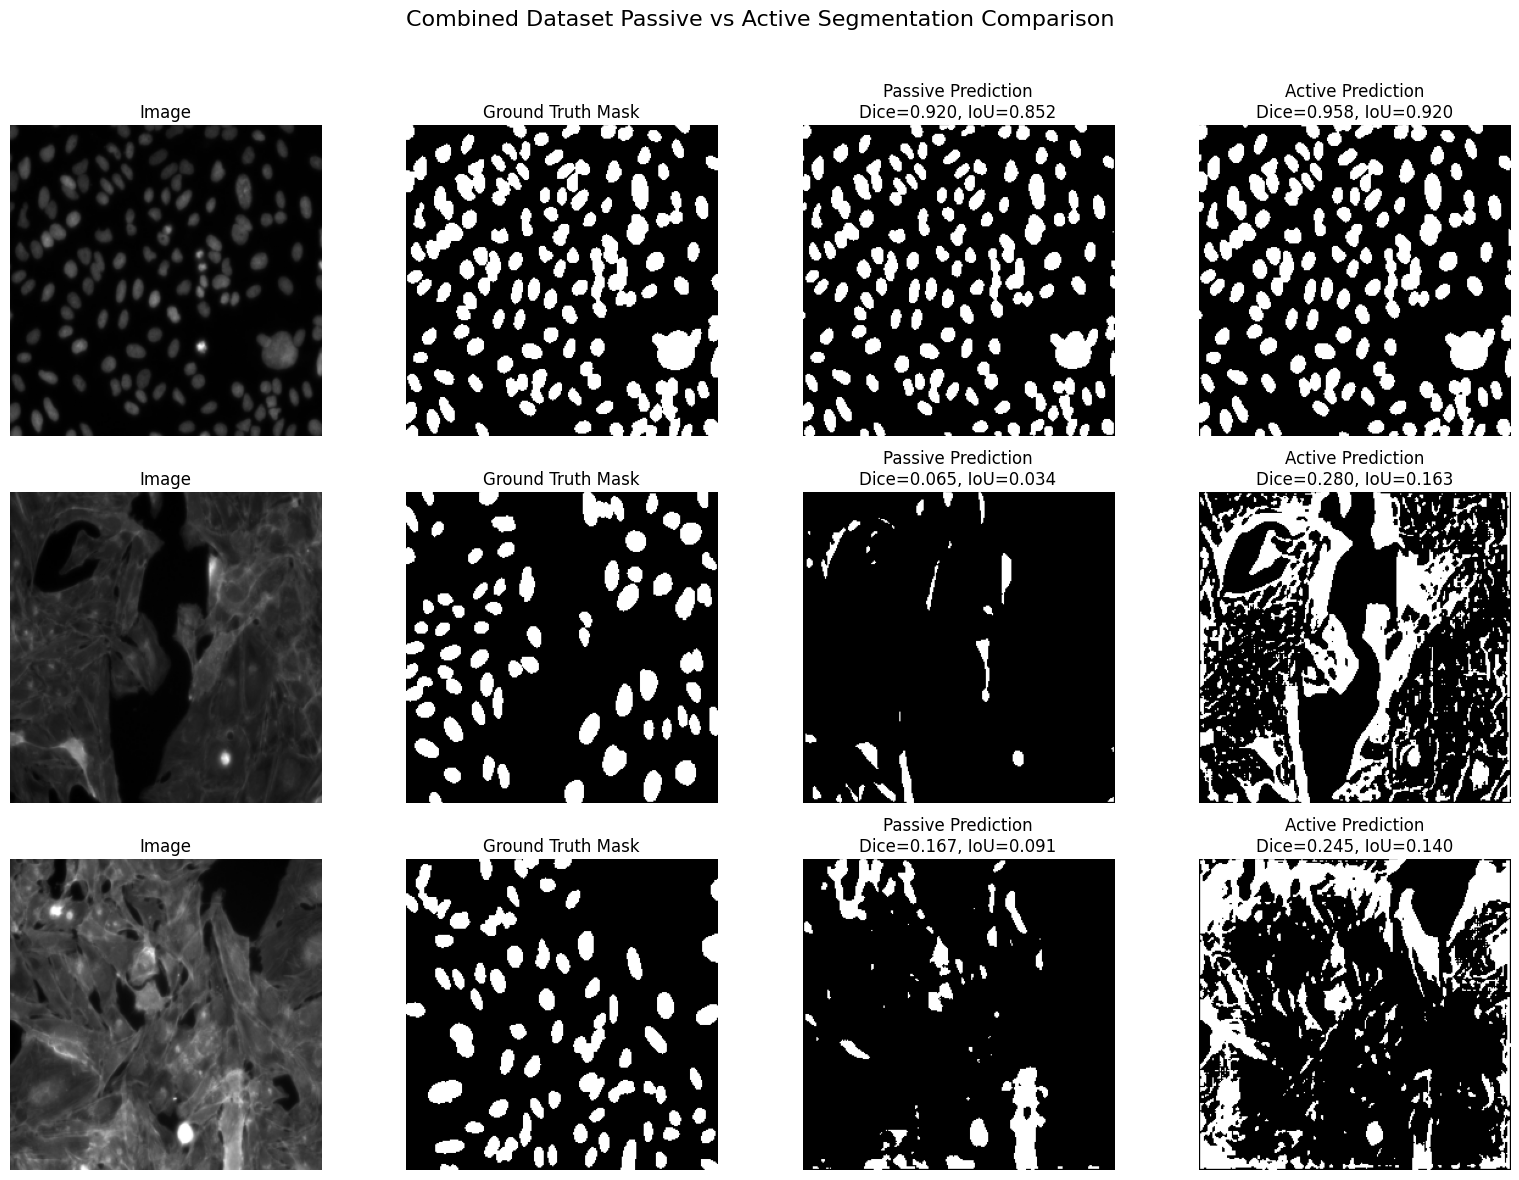

In [26]:
showPassiveActiveComparison(
    passiveNetwork=passiveTrainedNetwork,
    activeNetwork=activeTrainedNetwork,
    dataset=testSet,
    device=DEVICE,
    numberOfImages=3,
    threshold=0.5,
    figureTitle="Combined Dataset Passive vs Active Segmentation Comparison"
)